# Working with AgentSets
### The Boltzmann Wealth Model

**Important:**
- If you are just exploring Mesa and want the fastest way to execute the code we recommend executing this tutorial online in a Colab notebook. [![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mesa/mesa/blob/main/docs/tutorials/1_agentset.ipynb) or if you do not have a Google account you can use [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/mesa/mesa/main?labpath=docs%2Ftutorials%2F1_agentset.ipynb) (This can take 30 seconds to 5 minutes to load)
- If you are running locally, please ensure you have the latest Mesa version installed.
## Tutorial Description
This tutorial builds on the Boltzmann Wealth Model from the [First Model tutorial](0_first_model.ipynb).
In the first tutorial you created agents, put them in a model, and had them exchange money.
Now we'll explore **AgentSet** — Mesa's core tool for querying, filtering, grouping, and
inspecting collections of agents.
By the end of this tutorial, you will know how to:
- Retrieve attribute values from agents
- Filter agents with `select`
- Compute aggregate statistics with `agg`
- Group agents by attributes with `groupby`
- Combine these tools to answer questions about your model's state
The *next* tutorial covers how to use AgentSet for **activating** agents (calling their
methods). We separate these concerns because querying agents and activating agents are
conceptually different — you'll often query first and activate a subset.

### IN COLAB? - Run the next cell

In [1]:
%pip install --quiet mesa[rec]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 144.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.9/268.9 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 147.6 MB/s eta 0:00:00


### Import Dependencies

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

import mesa

## Setup: The Wealth Model with Ethnicities
We'll use a slightly enriched version of the Boltzmann Wealth Model. Each agent has a
`wealth` (starting at 1) and an `ethnicity` (randomly assigned from "Green", "Blue",
or "Mixed"). This gives us meaningful attributes to query, filter, and group by.

In [3]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth and an ethnicity."""

    def __init__(self, model, ethnicity):
        super().__init__(model)
        self.wealth = 1
        self.ethnicity = ethnicity

    def exchange(self):
        if self.wealth > 0:
            other_agent = self.random.choice(self.model.agents)
            other_agent.wealth += 1
            self.wealth -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=100):
        super().__init__()
        ethnicities = ["Green", "Blue", "Mixed"]
        MoneyAgent.create_agents(
            model=self,
            n=n,
            ethnicity=self.random.choices(ethnicities, k=n),
        )

    def step(self):
        self.agents.shuffle_do("exchange")

Let's create a model and run it for a while so agents have different wealth levels.

In [4]:
model = MoneyModel(100)
model.run_for(50)

## What is an AgentSet?
Every Mesa model automatically tracks all its agents in `model.agents`. This is an
**AgentSet** — an ordered collection of agents that provides powerful methods for
querying, filtering, and manipulating groups of agents.
You never need to create an AgentSet yourself for basic usage. Mesa creates and maintains
`model.agents` automatically whenever agents are added to or removed from the model.
Let's look at some basics:

In [5]:
# How many agents are in the model?
print(f"Total agents: {len(model.agents)}")

# Iterate over agents (just the first 5 for brevity)
for agent in model.agents.select(at_most=5):
    print(
        f"  Agent {agent.unique_id}: wealth={agent.wealth}, ethnicity={agent.ethnicity}"
    )

Total agents: 100
  Agent 1: wealth=1, ethnicity=Blue
  Agent 2: wealth=0, ethnicity=Green
  Agent 3: wealth=0, ethnicity=Mixed
  Agent 4: wealth=0, ethnicity=Mixed
  Agent 5: wealth=1, ethnicity=Mixed


## Retrieving Attribute Values with `get`
The `get` method retrieves attribute values from every agent in the set, returning them
as a list. This is useful whenever you want to inspect or analyze a particular attribute
across all agents.

In [6]:
# Get all wealth values
all_wealth = model.agents.get("wealth")
print(f"First 10 wealth values: {all_wealth[:10]}")
print(f"Total wealth in economy: {sum(all_wealth)}")

First 10 wealth values: [1, 0, 0, 0, 1, 1, 2, 2, 2, 0]
Total wealth in economy: 100


You can also retrieve multiple attributes at once by passing a list of attribute names.
This returns a list of lists — one inner list per agent.

In [7]:
# Get both wealth and ethnicity for each agent
wealth_and_ethnicity = model.agents.get(["wealth", "ethnicity"])
print("First 5 agents (wealth, ethnicity):")
for values in wealth_and_ethnicity[:5]:
    print(f"  {values}")

First 5 agents (wealth, ethnicity):
  [1, 'Blue']
  [0, 'Green']
  [0, 'Mixed']
  [0, 'Mixed']
  [1, 'Mixed']


### Handling missing attributes
If some agents might not have a particular attribute, you can use the `handle_missing`
parameter. By default, `get` raises an `AttributeError` for missing attributes. Setting
`handle_missing="default"` returns a default value instead.

In [8]:
# This would raise AttributeError if any agent lacks 'wealth':
# model.agents.get("nonexistent_attr")

# Safe alternative — returns None for missing attributes:
values = model.agents.get("wealth", handle_missing="default", default_value=0)
print(f"Retrieved {len(values)} values safely")

Retrieved 100 values safely


## Filtering Agents with `select`
The `select` method filters agents based on criteria, returning a new AgentSet containing
only the agents that match. This is one of the most frequently used AgentSet operations.
### Basic filtering with a function
Pass a function (often a lambda) that takes an agent and returns `True` or `False`:

In [9]:
# Select only wealthy agents (wealth >= 3)
rich_agents = model.agents.select(lambda a: a.wealth >= 3)
print(f"Rich agents (wealth >= 3): {len(rich_agents)}")

# Select agents with no money
broke_agents = model.agents.select(lambda a: a.wealth == 0)
print(f"Broke agents (wealth == 0): {len(broke_agents)}")

Rich agents (wealth >= 3): 10
Broke agents (wealth == 0): 41


### Filtering by agent type
If your model has multiple agent classes, you can filter by type using the `agent_type`
parameter. This is faster than using a lambda with `isinstance`.

In [10]:
# In this model we only have one type, but the syntax would be:
money_agents = model.agents.select(agent_type=MoneyAgent)
print(f"MoneyAgents: {len(money_agents)}")

MoneyAgents: 100


### Limiting results with `at_most`
The `at_most` parameter limits how many agents are returned. This is useful when you
only need a few agents and want to avoid processing the entire set.
- Pass an **integer** to get at most that many agents
- Pass a **float between 0 and 1** to get at most that fraction of agents
**Important:** `at_most` returns the *first* matching agents, not a random sample.
If you want a random subset, call `shuffle()` first (covered in the activation tutorial).

In [11]:
# Get at most 5 rich agents
some_rich = model.agents.select(lambda a: a.wealth >= 2, at_most=5)
print(f"Up to 5 rich agents: {len(some_rich)}")

# Get roughly 10% of agents
ten_percent = model.agents.select(at_most=0.1)
print(f"~10% of agents: {len(ten_percent)}")

Up to 5 rich agents: 5
~10% of agents: 10


### Combining criteria
You can combine `filter_func`, `agent_type`, and `at_most` in a single call. All
criteria are applied together (logical AND):

In [12]:
# At most 10 MoneyAgents with wealth > 0
subset = model.agents.select(
    filter_func=lambda a: a.wealth > 0,
    agent_type=MoneyAgent,
    at_most=10,
)
print(f"Subset size: {len(subset)}")

Subset size: 10


### Chaining selects
Since `select` returns an AgentSet, you can chain multiple calls. Each successive
`select` narrows the set further:

# Question 1.1
When we change the threshold to 5 we only see 1 wealthy green agent. With the threshold at 3, agents begin redistributing money once they reach 3 or more wealth. With the threshold at 5, agents can accumulate more wealth before they are selected to give money away.


In [13]:
# First get Green agents, then filter for wealthy ones
wealthy_green = model.agents.select(lambda a: a.ethnicity == "Green").select(
    lambda a: a.wealth >= 3
)
print(f"Wealthy Green agents: {len(wealthy_green)}")

Wealthy Green agents: 4


## Computing Aggregates with `agg`
The `agg` method computes aggregate statistics over an attribute for all agents in
the set. Pass the attribute name and a function (like `min`, `max`, `sum`, or `np.mean`).

In [17]:
# First get Green agents, then filter for wealthy ones
wealthy_green = model.agents.select(lambda a: a.ethnicity == "Green").select(
    lambda a: a.wealth >= 5
)
print(f"Wealthy Green agents: {len(wealthy_green)}")

Wealthy Green agents: 1


In [14]:
# Average wealth across all agents
avg_wealth = model.agents.agg("wealth", np.mean)
print(f"Average wealth: {avg_wealth:.2f}")

# Min and max wealth
min_wealth = model.agents.agg("wealth", min)
max_wealth = model.agents.agg("wealth", max)
print(f"Wealth range: {min_wealth} to {max_wealth}")

# Total wealth (should equal the number of agents, since money is conserved)
total = model.agents.agg("wealth", sum)
print(f"Total wealth: {total}")

Average wealth: 1.00
Wealth range: 0 to 5
Total wealth: 100


### Multiple aggregations at once
You can pass a list of functions to compute multiple statistics in a single call:

In [15]:
min_w, max_w, avg_w = model.agents.agg("wealth", [min, max, np.mean])
print(f"Min: {min_w}, Max: {max_w}, Mean: {avg_w:.2f}")

Min: 0, Max: 5, Mean: 1.00


### Aggregating subsets
Since `select` returns an AgentSet, you can chain `select` and `agg` to compute
statistics for specific subgroups:

In [16]:
# Average wealth of Green agents only
green_avg = model.agents.select(lambda a: a.ethnicity == "Green").agg("wealth", np.mean)
blue_avg = model.agents.select(lambda a: a.ethnicity == "Blue").agg("wealth", np.mean)
mixed_avg = model.agents.select(lambda a: a.ethnicity == "Mixed").agg("wealth", np.mean)

print(
    f"Average wealth — Green: {green_avg:.2f}, Blue: {blue_avg:.2f}, Mixed: {mixed_avg:.2f}"
)

Average wealth — Green: 0.89, Blue: 1.12, Mixed: 1.00


This pattern of select-then-aggregate is common, but when you want to do it for *all*
groups at once, `groupby` is more elegant.

# Question 1.2
The `else` block is not in this newer AgentSet notebook, but it appears in the assignment’s version of the select model. In that old version if there are no rich agents, the model goes to the `else` branch and poor agents give money to other poor agents.
I think alternatively we could introduce some new wealth into the poor agents, if they have a wealth of a really low value, we could increase it. Eventually harder working agents would become rich.

# Question 1.3
The gini coefficent is a measure of inequality. A Gini value of 0 means everyone has exactly the same wealth. A higher Gini value means wealth is more unequal, with some agents having much more wealth than others.

The gini coefficent rises, then stabilizes based on the graph. This happens because wealth is conserved, agents are not creating new money, they are only transferring it.

The `give_money()` logic would reduce extreme inequality because agents above the rich threshold give money to poorer agents. That redistribution prevents the richest agents from accumulating wealth without limit.

In [18]:
models = []

for steps in [20, 50, 100]:
    model = MoneyModel(100)
    model.run_for(steps)
    models.append((steps, model))

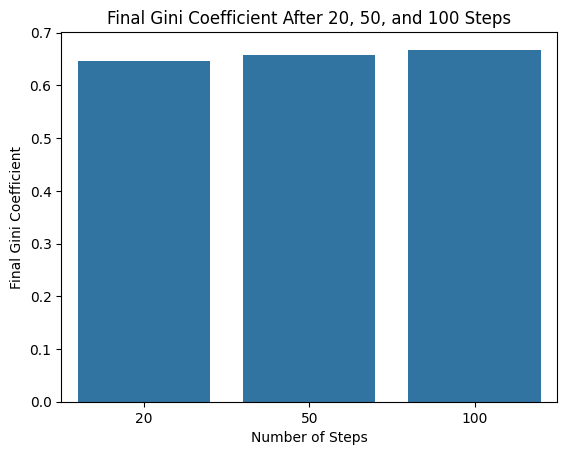

In [20]:
import matplotlib.pyplot as plt

results = []

for steps, model in models:
    wealths = sorted(model.agents.get("wealth"))
    n = len(wealths)
    total = sum(wealths)
    gini = 1 + (1 / n) - 2 * sum(x * (n - i) for i, x in enumerate(wealths)) / (n * total)

    results.append({
        "Steps": steps,
        "Gini": gini
    })

data = pd.DataFrame(results)

sns.barplot(data=data, x="Steps", y="Gini")
plt.title("Final Gini Coefficient After 20, 50, and 100 Steps")
plt.xlabel("Number of Steps")
plt.ylabel("Final Gini Coefficient")
plt.show()


## Grouping Agents with `groupby`
The `groupby` method splits agents into groups based on an attribute (or a callable),
returning a `GroupBy` object. This is conceptually similar to pandas' `groupby` and
is ideal when you want to analyze or act on agents by category.

In [ ]:
# Group agents by ethnicity
grouped = model.agents.groupby("ethnicity")

# See how many agents are in each group
print("Agents per ethnicity:", grouped.count())

### Iterating over groups
A `GroupBy` object is iterable. Each iteration yields a `(group_name, agent_set)` tuple:

In [ ]:
for ethnicity, group in grouped:
    avg = group.agg("wealth", np.mean)
    print(f"  {ethnicity}: {len(group)} agents, avg wealth = {avg:.2f}")

### Aggregating across groups
The `agg` method on `GroupBy` computes an aggregate for each group in one call:

In [ ]:
# Mean wealth by ethnicity
mean_by_group = grouped.agg("wealth", np.mean)
print("Mean wealth by ethnicity:", mean_by_group)

### Grouping by a function
Instead of an attribute name, you can pass a callable that computes the group key
for each agent. This is useful for creating custom groupings:

In [ ]:
# Group agents into wealth brackets
def wealth_bracket(agent):
    if agent.wealth == 0:
        return "broke"
    elif agent.wealth <= 2:
        return "modest"
    else:
        return "wealthy"


brackets = model.agents.groupby(wealth_bracket)
print("Agents per wealth bracket:", brackets.count())

# Question 2.4
Without using any weights parameter, the ethnicites are equally distributed so each of the three have a 33.3% chance. The modified version is below

In [22]:
ethnicities = ["Green", "Blue", "Mixed"]

model = MoneyModel(100)
new_ethnicities = model.random.choices(
    ethnicities,
    weights=[0.5, 0.3, 0.2],
    k=100
)

pd.Series(new_ethnicities).value_counts(normalize=True)


,proportion
Green,0.43
Blue,0.36
Mixed,0.21


# Question 2.5
`model.agents.groupby("ethnicity")` returns a Mesa `GroupBy` object. It groups the agents by their ethnicity value. When we loop through it, each item gives us the ethnicity name and the `AgentSet` of agents in that group.

Implementation for Red ethnicity only trading with Mixed below

In [24]:
model = MoneyModel(100)

# Add a fourth ethnicity by changing some agents to Red
for agent in model.agents.select(at_most=10):
    agent.ethnicity = "Red"

print("Agents per ethnicity:", model.agents.groupby("ethnicity").count())

# One group-based trading step
for ethnicity, group in model.agents.groupby("ethnicity"):
    if ethnicity == "Mixed":
        trade_partners = model.agents
    elif ethnicity == "Red":
        trade_partners = model.agents.select(lambda a: a.ethnicity == "Mixed")
    else:
        trade_partners = group

    for agent in group.shuffle():
        if agent.wealth > 0 and len(trade_partners) > 0:
            other_agent = agent.random.choice(trade_partners)
            other_agent.wealth += 1
            agent.wealth -= 1

for ethnicity, group in model.agents.groupby("ethnicity"):
    print(f"{ethnicity}: average wealth = {group.agg('wealth', np.mean):.2f}")


Agents per ethnicity: {'Red': 10, 'Green': 27, 'Blue': 26, 'Mixed': 37}
Red: average wealth = 0.20
Green: average wealth = 1.37
Blue: average wealth = 1.31
Mixed: average wealth = 0.73


# Question 2.6
After running the model for 100 steps, I grouped the data by ethnicity and calculated the average wealth for each group.

The ethnicity with the highest average wealth was Mixed. Each time I run it is different.

Mixed agents can have an advantage in the assignment's group-based model because they are allowed to trade with anyone, while Green and Blue agents are limited to trading mostly inside their own ethnicity. This gives Mixed agents access to a larger trading network. This can also be a disadvantage since Mixed agents can also lose money to more agents.

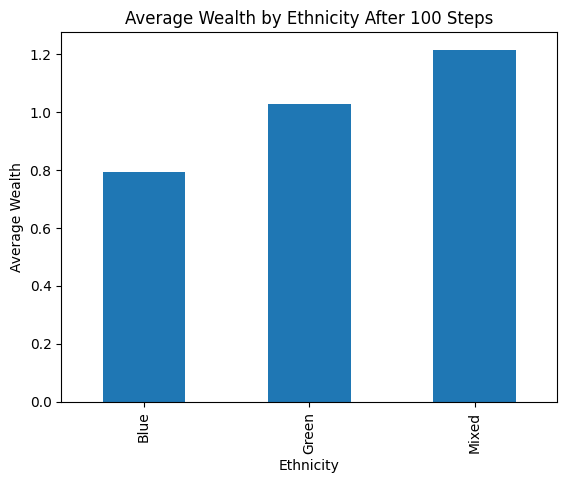

,Wealth
Ethnicity,
Mixed,1.214286
Green,1.026316
Blue,0.794118


In [27]:
model = MoneyModel(100)
model.run_for(100)

data = pd.DataFrame({
    "Ethnicity": model.agents.get("ethnicity"),
    "Wealth": model.agents.get("wealth")
})

data.groupby("Ethnicity")["Wealth"].mean().plot(kind="bar")
plt.title("Average Wealth by Ethnicity After 100 Steps")
plt.xlabel("Ethnicity")
plt.ylabel("Average Wealth")
plt.show()
data.groupby("Ethnicity")["Wealth"].mean().sort_values(ascending=False)


## Setting Attributes with `set`
The `set` method assigns a value to an attribute for all agents in the set. This is
useful for bulk updates — for example, applying a policy change to a group of agents.

In [ ]:
# Give all broke agents a subsidy of 1
broke = model.agents.select(lambda a: a.wealth == 0)
print(f"Broke agents before subsidy: {len(broke)}")

broke.set("wealth", 1)

# Verify
still_broke = model.agents.select(lambda a: a.wealth == 0)
print(f"Broke agents after subsidy: {len(still_broke)}")

**Note:** `set` modifies agents in place and returns the AgentSet, so you can chain it:
```python
model.agents.select(lambda a: a.wealth > 10).set("taxed", True)
```

## Sorting Agents with `sort`
The `sort` method orders agents by an attribute or a custom key function. By default,
it returns a new sorted AgentSet (use `inplace=True` to sort in place).

In [ ]:
# Sort by wealth (descending by default)
richest_first = model.agents.sort("wealth")
top_5 = richest_first.select(at_most=5)
print("Top 5 wealthiest agents:")
for agent in top_5:
    print(f"  Agent {agent.unique_id}: wealth={agent.wealth}")

# Sort ascending
poorest_first = model.agents.sort("wealth", ascending=True)
bottom_5 = poorest_first.select(at_most=5)
print("\nBottom 5:")
for agent in bottom_5:
    print(f"  Agent {agent.unique_id}: wealth={agent.wealth}")

## Converting to a List
If you need standard list operations like indexing or slicing, use the `to_list()` method
to convert the AgentSet to a plain Python list:

In [ ]:
agent_list = model.agents.to_list()
print(f"First agent: {agent_list[0].unique_id}")
print(f"Last agent: {agent_list[-1].unique_id}")

## Putting It Together: Analyzing the Model
Let's combine what we've learned to produce a summary analysis of the model state.

In [ ]:
print("=== Model Summary After 50 Steps ===\n")

# Overall statistics
min_w, max_w, avg_w, total_w = model.agents.agg("wealth", [min, max, np.mean, sum])
print(f"Agents: {len(model.agents)}")
print(
    f"Total wealth: {total_w} (conserved: {'yes' if total_w == len(model.agents) else 'no, subsidy applied'})"
)
print(f"Wealth range: {min_w} to {max_w}, mean: {avg_w:.2f}\n")

# By ethnicity
print("By ethnicity:")
for ethnicity, group in model.agents.groupby("ethnicity"):
    count = len(group)
    avg = group.agg("wealth", np.mean)
    broke = len(group.select(lambda a: a.wealth == 0))
    print(
        f"  {ethnicity:6s}: {count:3d} agents, avg wealth = {avg:.2f}, broke = {broke}"
    )

# Wealth distribution
print("\nWealth brackets:")
for bracket, group in model.agents.groupby(wealth_bracket):
    print(f"  {bracket:8s}: {len(group)} agents")

## Visualizing the Results

In [ ]:
# Collect data for plotting
data = []
for agent in model.agents:
    data.append({"wealth": agent.wealth, "ethnicity": agent.ethnicity})
df = pd.DataFrame(data)

palette = {"Green": "green", "Blue": "blue", "Mixed": "purple"}
g = sns.histplot(data=df, x="wealth", hue="ethnicity", discrete=True, palette=palette)
g.set(
    title="Wealth distribution by ethnicity", xlabel="Wealth", ylabel="Number of agents"
)

## Summary
In this tutorial you learned the core AgentSet **query** methods:
| Method | Purpose |
|---|---|
| `get(attr)` | Retrieve attribute values from all agents |
| `select(func)` | Filter agents by criteria |
| `agg(attr, func)` | Compute aggregate statistics |
| `groupby(attr)` | Group agents by attribute or function |
| `set(attr, value)` | Bulk-assign attribute values |
| `sort(key)` | Order agents by attribute |
| `to_list()` | Convert to a plain Python list |
These methods are about *inspecting* and *organizing* agents. In the next tutorial,
we'll cover how to **activate** agents — making them actually *do* things — using
`do`, `shuffle_do`, and `map`.

## Next Steps
Check out the [Agent Activation tutorial](2_agent_activation)
to learn how to make your agents act, in different orders and patterns.


# Question 3.7

After 100 steps the group-by model produces more inequality. See the graphs below.

The select model should usually be more effective at reducing inequality because it moves wealth from rich agents to poor agents. The group-by model does not directly target poor agents. It mainly limits who can trade with who so inequality can still develop inside each group.



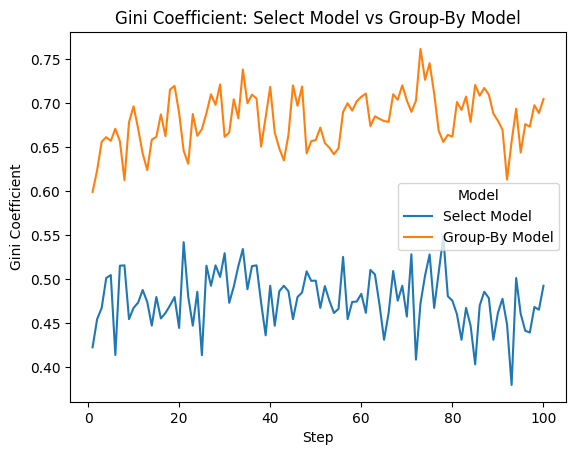

,Step,Gini,Model
99,100,0.4926,Select Model
199,100,0.7050,Group-By Model


In [28]:
results = []

for model_name in ["Select Model", "Group-By Model"]:
    model = MoneyModel(100)

    for step in range(100):
        model.step()

        if model_name == "Select Model":
            rich_agents = model.agents.select(lambda a: a.wealth >= 3)
            poor_agents = model.agents.select(lambda a: a.wealth < 3)

            if len(rich_agents) > 0:
                for agent in rich_agents.shuffle():
                    if agent.wealth > 0 and len(poor_agents) > 0:
                        other_agent = agent.random.choice(poor_agents)
                        other_agent.wealth += 1
                        agent.wealth -= 1

        if model_name == "Group-By Model":
            for ethnicity, group in model.agents.groupby("ethnicity"):
                if ethnicity == "Mixed":
                    trade_partners = model.agents
                else:
                    trade_partners = group

                for agent in group.shuffle():
                    if agent.wealth > 0 and len(trade_partners) > 0:
                        other_agent = agent.random.choice(trade_partners)
                        other_agent.wealth += 1
                        agent.wealth -= 1

        wealths = sorted(model.agents.get("wealth"))
        n = len(wealths)
        total = sum(wealths)
        gini = 1 + (1 / n) - 2 * sum(x * (n - i) for i, x in enumerate(wealths)) / (n * total)

        results.append({
            "Step": step + 1,
            "Gini": gini,
            "Model": model_name
        })

data = pd.DataFrame(results)

sns.lineplot(data=data, x="Step", y="Gini", hue="Model")
plt.title("Gini Coefficient: Select Model vs Group-By Model")
plt.xlabel("Step")
plt.ylabel("Gini Coefficient")
plt.show()

data.groupby("Model").tail(1)


# Question 3.8
An effective trading network for each ethnicity is each one goes to itself and mixed go to any ethinicty

Green agents trade with Green agents.  
Blue agents trade with Blue agents.  
Mixed agents trade with Green, Blue, and Mixed agents.






If the Mixed ethnicity is removed, then Green and Blue become separate trading groups. Green agents only trade with Green agents, and Blue agents only trade with Blue agents. This means wealth moves inside poor to rich in each group but not between the ethnicities

Group size changes wealth distribution because larger groups have more possible trading partners. If Green = 70%, Blue = 20%, and Mixed = 10%, Green agents have a much larger network than Blue agents. The smaller Blue and Mixed groups may have more random outcomes because there are fewer agents. With an equal distribution, the trading opportunities are more balanced across ethnicities.


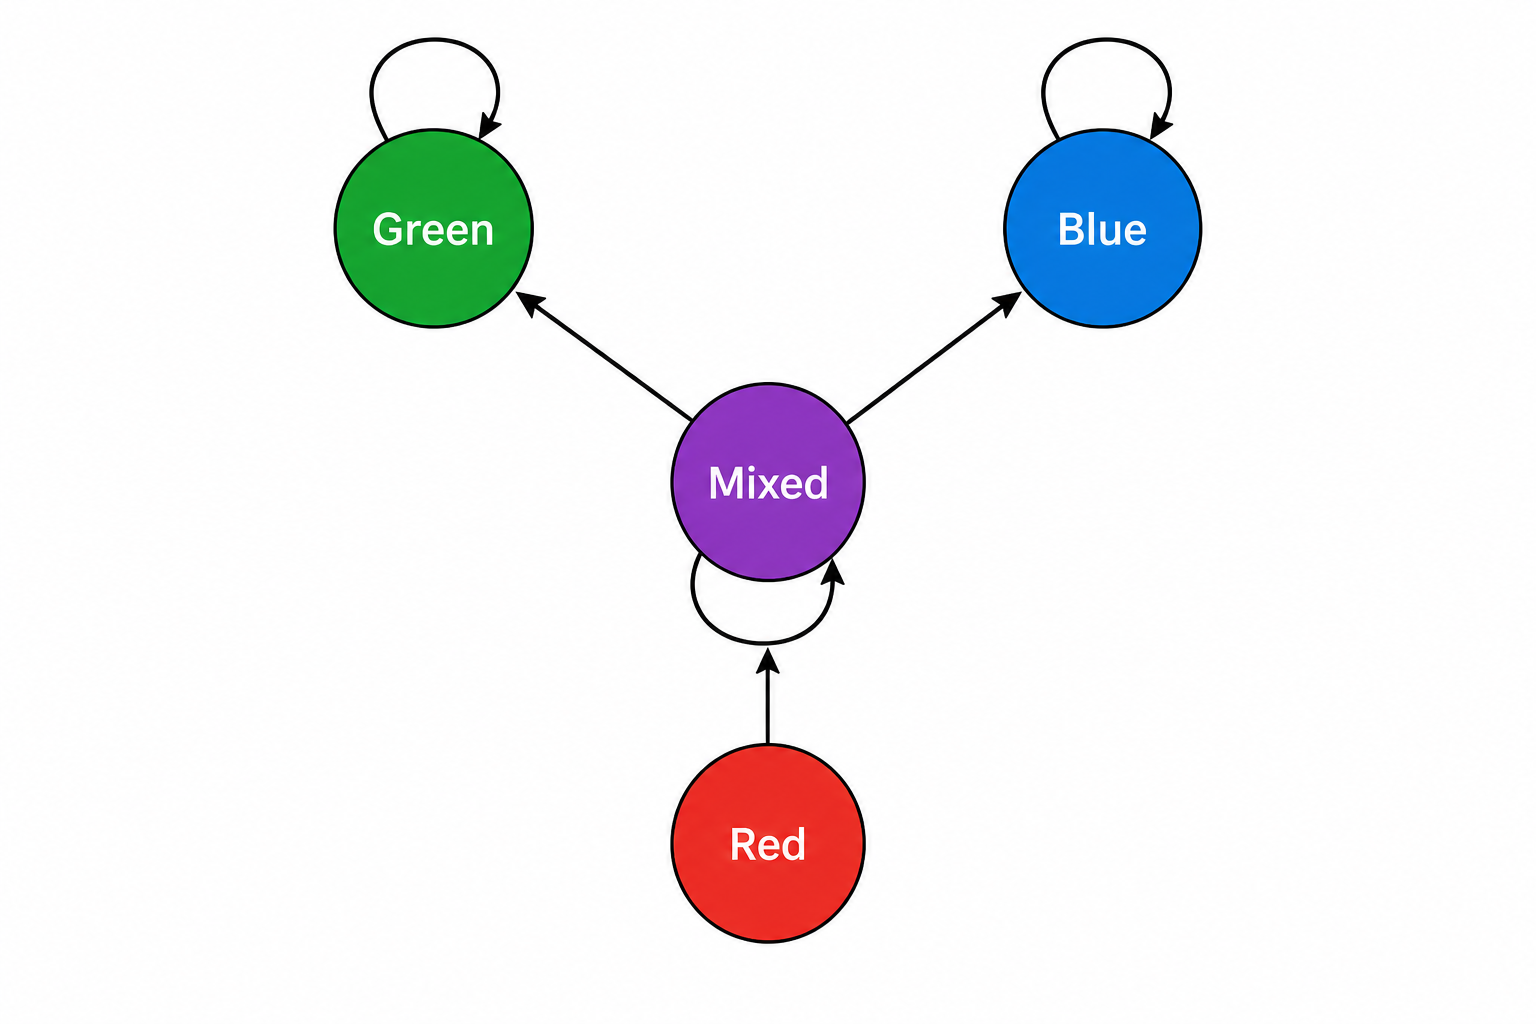

In [31]:
results = []

for scenario, ethnicities, weights in [
    ("No Mixed", ["Green", "Blue"], [0.5, 0.5]),
    ("Green 70 Blue 20 Mixed 10", ["Green", "Blue", "Mixed"], [0.7, 0.2, 0.1]),
    ("Equal Distribution", ["Green", "Blue", "Mixed"], [1/3, 1/3, 1/3])
]:
    model = MoneyModel(100)

    new_ethnicities = model.random.choices(ethnicities, weights=weights, k=100)
    for agent, ethnicity in zip(model.agents, new_ethnicities):
        agent.ethnicity = ethnicity

    for step in range(100):
        for ethnicity, group in model.agents.groupby("ethnicity"):
            if ethnicity == "Mixed":
                trade_partners = model.agents
            else:
                trade_partners = group

            for agent in group.shuffle():
                if agent.wealth > 0 and len(trade_partners) > 0:
                    other_agent = agent.random.choice(trade_partners)
                    other_agent.wealth += 1
                    agent.wealth -= 1

    wealths = sorted(model.agents.get("wealth"))
    n = len(wealths)
    total = sum(wealths)
    gini = 1 + (1 / n) - 2 * sum(x * (n - i) for i, x in enumerate(wealths)) / (n * total)

    results.append({
        "Scenario": scenario,
        "Gini": gini
    })

data = pd.DataFrame(results)
data


,Scenario,Gini
0,No Mixed,0.5956
1,Green 70 Blue 20 Mixed 10,0.6516
2,Equal Distribution,0.7214


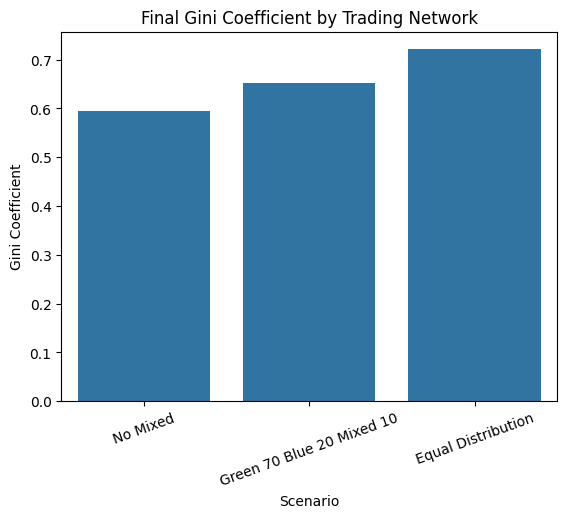

In [32]:
sns.barplot(data=data, x="Scenario", y="Gini")
plt.title("Final Gini Coefficient by Trading Network")
plt.xlabel("Scenario")
plt.ylabel("Gini Coefficient")
plt.xticks(rotation=20)
plt.show()


# Question 4.9

The hybrid model produces the least inequality but pretty close to the select model, and the group-by produces the most. This changes on every run.

Compared to the select model, the hybrid model is more restricted because Green and Blue agents do not always give to any poor agent. Compared to the group-by model, it is more redistributive because only richer agents give money and the recipients are poorer agents.


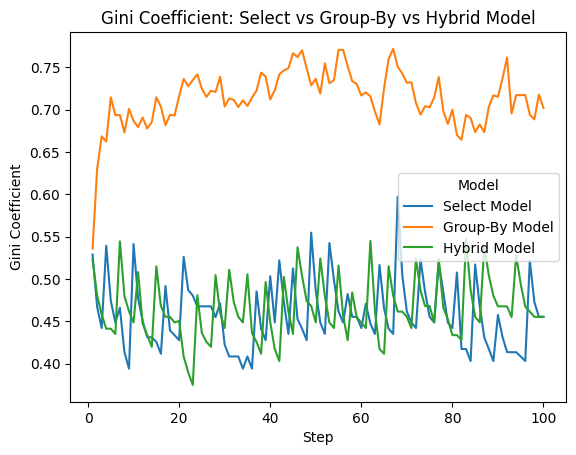

,Step,Gini,Model
99,100,0.4554,Select Model
199,100,0.7020,Group-By Model
299,100,0.4554,Hybrid Model


In [35]:
results = []

for model_name in ["Select Model", "Group-By Model", "Hybrid Model"]:
    model = MoneyModel(100)

    for step in range(100):
        if model_name == "Select Model":
            rich_agents = model.agents.select(lambda a: a.wealth >= 3)
            poor_agents = model.agents.select(lambda a: a.wealth < 3)

            if len(rich_agents) > 0:
                acting_agents = rich_agents
            else:
                acting_agents = poor_agents

            for agent in acting_agents.shuffle():
                if agent.wealth > 0 and len(poor_agents) > 0:
                    other_agent = agent.random.choice(poor_agents)
                    other_agent.wealth += 1
                    agent.wealth -= 1

        elif model_name == "Group-By Model":
            for ethnicity, group in model.agents.groupby("ethnicity"):
                if ethnicity == "Mixed":
                    trade_partners = model.agents
                else:
                    trade_partners = group

                for agent in group.shuffle():
                    if agent.wealth > 0 and len(trade_partners) > 0:
                        other_agent = agent.random.choice(trade_partners)
                        other_agent.wealth += 1
                        agent.wealth -= 1

        else:
            rich_agents = model.agents.select(lambda a: a.wealth >= 3)

            if len(rich_agents) > 0:
                for agent in rich_agents.shuffle():
                    if agent.ethnicity == "Mixed":
                        possible_receivers = model.agents.select(lambda a: a.wealth < 3)
                    else:
                        possible_receivers = model.agents.select(
                            lambda a: a.ethnicity == agent.ethnicity and a.wealth < 3
                        )

                        if len(possible_receivers) == 0:
                            possible_receivers = model.agents.select(
                                lambda a: a.ethnicity == "Mixed" and a.wealth < 3
                            )

                    if agent.wealth > 0 and len(possible_receivers) > 0:
                        other_agent = agent.random.choice(possible_receivers)
                        other_agent.wealth += 1
                        agent.wealth -= 1
            else:
                model.step()

        wealths = sorted(model.agents.get("wealth"))
        n = len(wealths)
        total = sum(wealths)
        gini = 1 + (1 / n) - 2 * sum(x * (n - i) for i, x in enumerate(wealths)) / (n * total)

        results.append({
            "Step": step + 1,
            "Gini": gini,
            "Model": model_name
        })

data = pd.DataFrame(results)

sns.lineplot(data=data, x="Step", y="Gini", hue="Model")
plt.title("Gini Coefficient: Select vs Group-By vs Hybrid Model")
plt.xlabel("Step")
plt.ylabel("Gini Coefficient")
plt.show()

data.groupby("Model").tail(1)


# Question 4.10

For the policy intervention, every 10 steps, agents with wealth greater than 5 pay 1 unit of wealth. The collected wealth is then distributed to agents with wealth less than 2.

Looking at the graph it very slightly reduces inequality. On this run, it reduced by 2.15% but is different on each run.

The tax policy directly targets high-wealth and low-wealth agents, so the final Gini coefficient should usually be lower with the policy than without it.


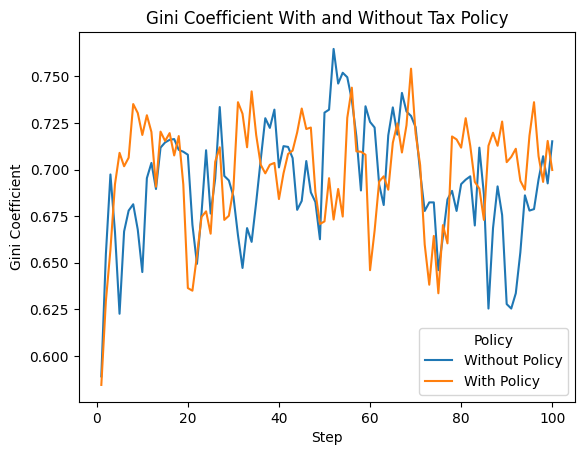

     Step    Gini          Policy
99    100  0.7152  Without Policy
199   100  0.6998     With Policy
Percentage reduction in final Gini coefficient: 2.15%


In [37]:
results = []

for policy in ["Without Policy", "With Policy"]:
    model = MoneyModel(100)

    for step in range(100):
        for ethnicity, group in model.agents.groupby("ethnicity"):
            if ethnicity == "Mixed":
                trade_partners = model.agents
            else:
                trade_partners = group

            for agent in group.shuffle():
                if agent.wealth > 0 and len(trade_partners) > 0:
                    other_agent = agent.random.choice(trade_partners)
                    other_agent.wealth += 1
                    agent.wealth -= 1

        if policy == "With Policy" and (step + 1) % 10 == 0:
            rich_agents = model.agents.select(lambda a: a.wealth > 5)
            poor_agents = model.agents.select(lambda a: a.wealth < 2)

            collected = 0
            for agent in rich_agents:
                agent.wealth -= 1
                collected += 1

            if len(poor_agents) > 0 and collected > 0:
                equal_share = collected // len(poor_agents)
                remainder = collected % len(poor_agents)

                for agent in poor_agents:
                    agent.wealth += equal_share

                for i in range(remainder):
                    agent = model.random.choice(poor_agents)
                    agent.wealth += 1

        wealths = sorted(model.agents.get("wealth"))
        n = len(wealths)
        total = sum(wealths)
        gini = 1 + (1 / n) - 2 * sum(x * (n - i) for i, x in enumerate(wealths)) / (n * total)

        results.append({
            "Step": step + 1,
            "Gini": gini,
            "Policy": policy
        })

data = pd.DataFrame(results)

sns.lineplot(data=data, x="Step", y="Gini", hue="Policy")
plt.title("Gini Coefficient With and Without Tax Policy")
plt.xlabel("Step")
plt.ylabel("Gini Coefficient")
plt.show()

final_gini = data.groupby("Policy").tail(1)
print(final_gini)

without_policy = final_gini[final_gini["Policy"] == "Without Policy"]["Gini"].iloc[0]
with_policy = final_gini[final_gini["Policy"] == "With Policy"]["Gini"].iloc[0]

reduction = ((without_policy - with_policy) / without_policy) * 100
print(f"Percentage reduction in final Gini coefficient: {reduction:.2f}%")
